In [1]:
import cv2 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df =pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\NLP\\Day11\\letterdata.csv")

In [3]:
df

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19998,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


In [4]:
df.shape

(20000, 17)

## sepearte the iput and output variables 

In [5]:
x = df.drop('letter', axis = 1)
y = df['letter']

<Axes: xlabel='count', ylabel='letter'>

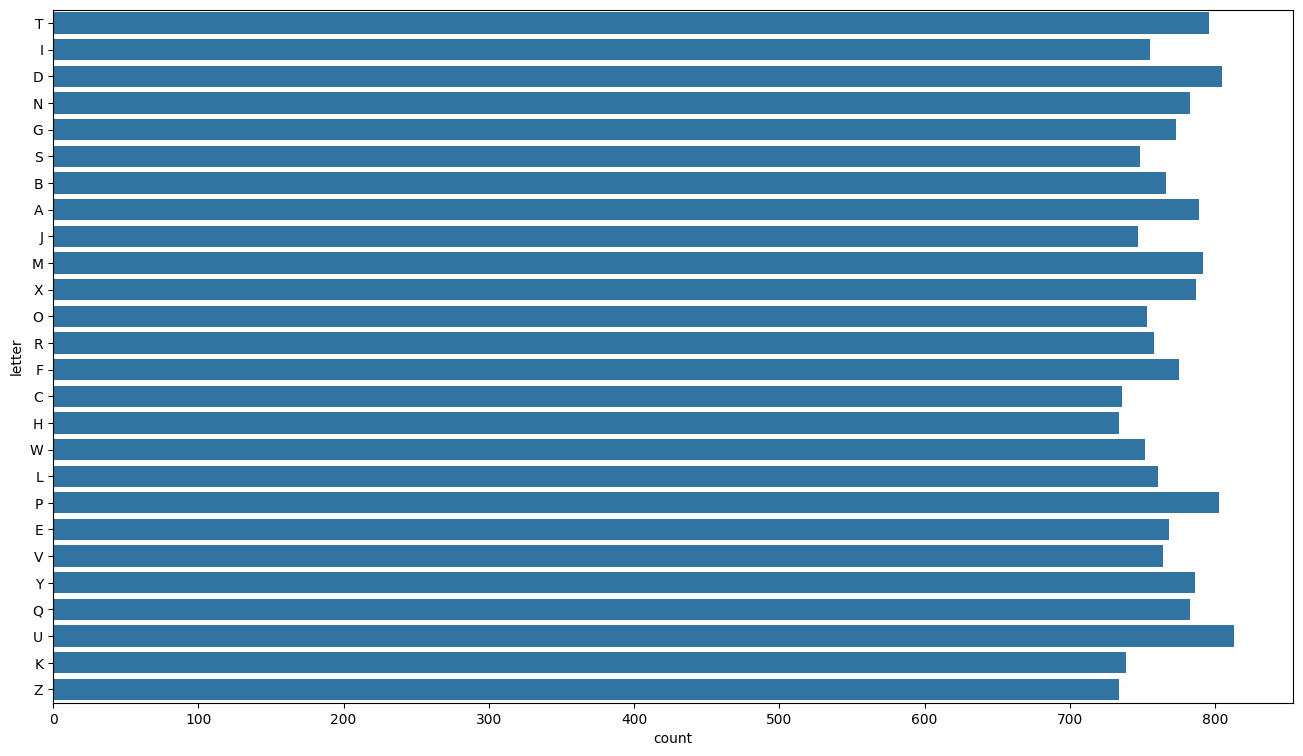

In [6]:
plt.figure(figsize=(16,9))
sns.countplot(y = y)

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, random_state=0, test_size=0.2)

In [8]:
x_train.shape

(16000, 16)

In [9]:
x_test.shape

(4000, 16)

# Build the model

In [10]:
from sklearn.ensemble import RandomForestClassifier

In [11]:
rf=RandomForestClassifier(random_state=0, n_estimators=20)

In [12]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

#

In [13]:
from sklearn.metrics import accuracy_score,classification_report

In [14]:
y_pred=rf.predict(x_test)

In [15]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           A       0.97      0.99      0.98       147
           B       0.89      0.95      0.92       158
           C       0.97      0.97      0.97       156
           D       0.90      0.96      0.93       171
           E       0.94      0.92      0.93       145
           F       0.94      0.92      0.93       167
           G       0.92      0.93      0.93       182
           H       0.91      0.85      0.88       123
           I       0.97      0.92      0.94       127
           J       0.97      0.94      0.96       159
           K       0.92      0.92      0.92       143
           L       0.97      0.96      0.97       159
           M       0.97      0.95      0.96       173
           N       0.96      0.96      0.96       134
           O       0.97      0.98      0.98       142
           P       0.96      0.96      0.96       165
           Q       0.94      0.99      0.96       145
           R       0.92    

In [16]:
accuracy_score(y_test,y_pred)

0.953

In [17]:
rf.feature_importances_

array([0.02239203, 0.02566732, 0.02311828, 0.02154923, 0.02537044,
       0.05488616, 0.06409146, 0.08168569, 0.09808875, 0.07414187,
       0.07924167, 0.08115063, 0.1222804 , 0.07335313, 0.09756412,
       0.05541881])

In [18]:
new=x_test.iloc[[100],:]

In [19]:
new

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
18044,1,3,2,1,1,7,7,5,5,6,6,9,2,8,3,9


In [20]:
rf.predict(new)

array(['G'], dtype=object)

In [21]:
y_test.iloc[100]

'G'